# 07 - Baseline & Model Comparison

Consolidates the baseline and five models so far (Logistic Regression, Random Forest, XGBoost, SVM, Neural Network) into one comparison, all evaluated on the same validation set. This is the evidence base for Stage 8's tuning priorities and Stage 9's final recommendation.

**Reminder:** everything here is validation set performance. The test set remains completely untouched until Stage 7 opens it exactly once for final evaluation.


## Load all metrics files

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

metrics_files = {
    'Rule-based baseline': '../../../data/processed/metrics_baseline.json',
    'Logistic Regression': '../../../data/processed/metrics_logreg.json',
    'Random Forest': '../../../data/processed/metrics_rf.json',
    'XGBoost': '../../../data/processed/metrics_xgb.json',
    'SVM (Linear)': '../../../data/processed/metrics_svm.json',
    'Neural Network': '../../../data/processed/metrics_nn.json',
}

all_metrics = []
for name, path in metrics_files.items():
    with open(path) as f:
        all_metrics.append(json.load(f))

comparison_df = pd.DataFrame(all_metrics).set_index('model')
comparison_df = comparison_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].round(4)
comparison_df.sort_values('recall', ascending=False)


,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.6172,0.7924,0.6939,0.7580,0.8234
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
Neural Network (PyTorch),0.5857,0.8458,0.6921,0.7653,0.8301
SVM (Linear),0.5618,0.8394,0.6731,0.7392,0.8102
Logistic Regression,0.5543,0.8379,0.6672,0.7394,0.8105
Rule based baseline,0.5349,0.8391,0.6533,0.7270,0.7429


## Visual comparison 

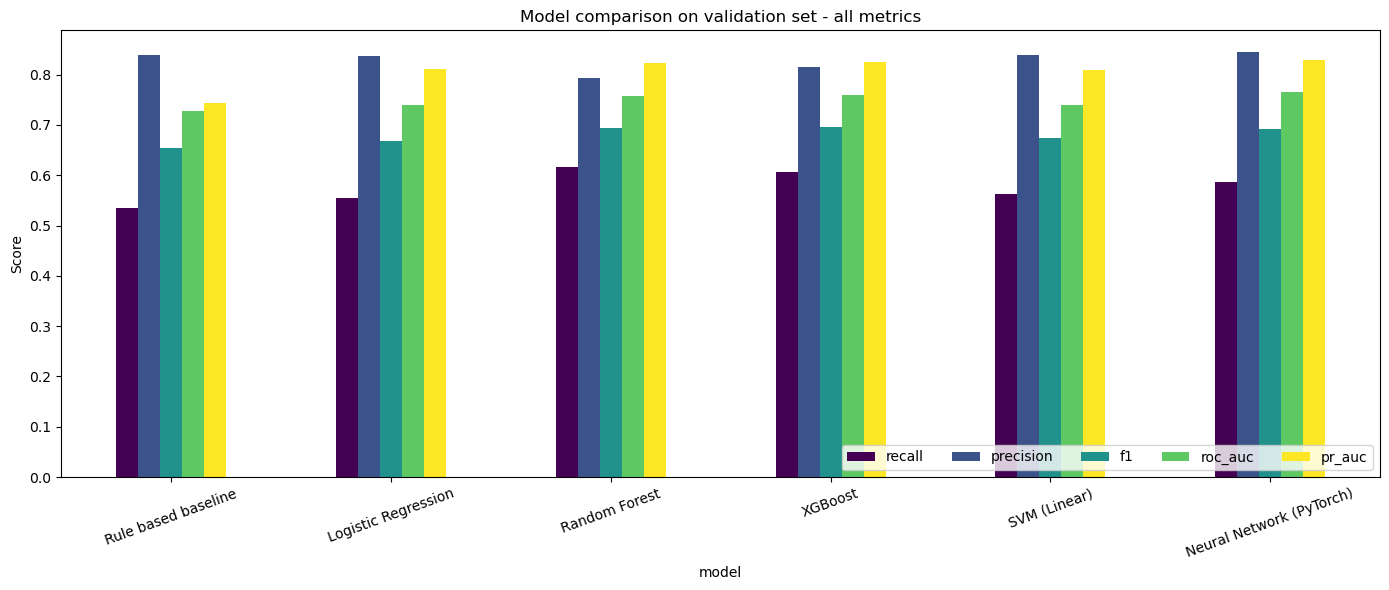

In [3]:
comparison_df.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Model comparison on validation set - all metrics')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right', ncol=5)
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()


## Heatmap view 

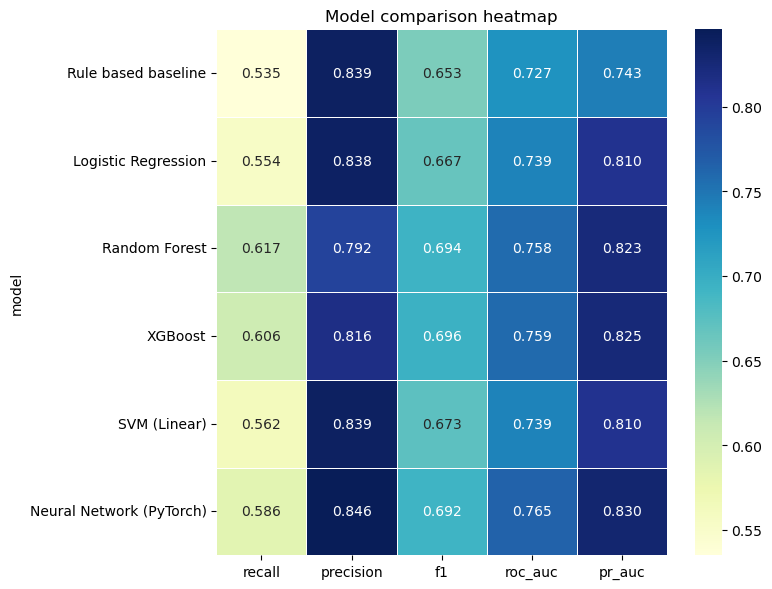

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Model comparison heatmap')
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found (interim snapshot, 6 of 12 planned models):**

**No single model dominates every metric, this is the headline finding, not a lack of a clear winner:**

- **Best Recall (primary metric): Random Forest (0.6172)**, followed closely by XGBoost (0.6062). This is the metric that matters most given our cost-sensitivity reasoning, so Random Forest currently leads the comparison where it counts most.
- **Best ROC-AUC, PR-AUC, and Precision: Neural Network** (0.7653, 0.8301, 0.8458 respectively), a genuinely unexpected result given the intro to that notebook explicitly didn't expect it to beat the tree-based models. It doesn't lead on Recall, but it's the strongest model at ranking orders by risk overall.
- **XGBoost sits essentially tied with Random Forest on F1 (0.6956 vs 0.6939) and close behind on every other metric**, effectively a co-leader rather than clearly behind.
- **The gap between the baseline and the best model (Random Forest) is 8.2 percentage points of Recall** (0.5349 to 0.6172), a real, meaningful improvement, not a marginal one, confirming the rule-based baseline was a genuinely useful comparison floor to have set correctly (after the fix earlier).
- **SVM and Logistic Regression land almost on top of each other** (confirmed in Notebook 05, SVM doesn't add anything distinct from Logistic Regression once properly converged).

**Carrying forward:** Random Forest, XGBoost, and the Neural Network all look like genuine contenders heading into the rest of the comparison, none should be eliminated yet. This snapshot is not the final word, the boosting family notebooks (LightGBM, CatBoost, Gradient Boosting, AdaBoost) and the two ensemble notebooks (Voting, Stacking) are still to come, and the actual final ranking lives in `14_model_comparison.ipynb` once all twelve models are in. 
